# Model Training - Robust CNN-BiLSTM-Attention

This notebook follows a practical methodology inspired by your earlier baseline notebooks, adapted to this project pipeline:

1. Load window arrays (or rebuild safely if invalid)
2. Normalize features using training-only statistics
3. Train CNN + BiLSTM + temporal attention with focal loss
4. Tune decision threshold on validation PR curve (recall-focused)
5. Evaluate on test set with PR/ROC/F1 and confusion matrix

Goal: stable generalization and reduced overfitting under class imbalance.

In [199]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow.keras.backend as K

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Dropout,
    Bidirectional, LSTM, Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

DATA_DIR = "../data"
MODEL_DIR = "../models"
FIG_DIR = "../paper/images"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

tf.random.set_seed(42)
np.random.seed(42)

WINDOW_SIZE = 20
STEP_SIZE = 5
FORCE_REBUILD_WINDOWS = True
FEATURES = [
    "Pressure (bar)", "Flow Rate (L/s)", "Temperature (°C)",
    "pressure_delta", "flow_zscore", "pf_ratio"
]

print(f"TensorFlow {tf.__version__}")

TensorFlow 2.21.0


In [200]:
def create_windows_for_group(group_df, features, window_size=20, step_size=5):
    vals = group_df[features].values
    labels = group_df["Leak Status"].values

    X_list, y_list = [], []
    for start in range(0, len(group_df) - window_size + 1, step_size):
        end = start + window_size
        X_list.append(vals[start:end])
        # Baseline-style labeling: leak if ANY timestep in the window is leak
        y_list.append(int(labels[start:end].max() > 0))
    return X_list, y_list


def ensure_engineered_columns(df):
    needed = {"pressure_delta", "flow_zscore", "pf_ratio"}
    if needed.issubset(df.columns):
        return df

    df = df.sort_values(["Sensor_ID", "Timestamp"]).reset_index(drop=True).copy()

    if "pressure_delta" not in df.columns:
        df["pressure_delta"] = df.groupby("Sensor_ID")["Pressure (bar)"].diff().fillna(0)

    if "pf_ratio" not in df.columns:
        df["pf_ratio"] = df["Pressure (bar)"] / (df["Flow Rate (L/s)"] + 1e-8)

    if "flow_zscore" not in df.columns:
        sensor_mu = df.groupby("Sensor_ID")["Flow Rate (L/s)"].transform("mean")
        sensor_sd = df.groupby("Sensor_ID")["Flow Rate (L/s)"].transform("std").fillna(0)
        df["flow_zscore"] = (df["Flow Rate (L/s)"] - sensor_mu) / (sensor_sd + 1e-8)

    return df


def fallback_split_with_positive_guard(X_all, y_all, seed=42):
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y_all == 1)[0]
    neg_idx = np.where(y_all == 0)[0]

    rng.shuffle(pos_idx)
    rng.shuffle(neg_idx)

    # Reserve positives for validation/test when possible
    val_pos = pos_idx[:1] if len(pos_idx) >= 1 else np.array([], dtype=int)
    test_pos = pos_idx[1:2] if len(pos_idx) >= 2 else np.array([], dtype=int)
    train_pos = pos_idx[2:] if len(pos_idx) >= 3 else np.array([], dtype=int)

    n_neg = len(neg_idx)
    tr_end = int(n_neg * 0.70)
    va_end = int(n_neg * 0.85)

    train_neg = neg_idx[:tr_end]
    val_neg = neg_idx[tr_end:va_end]
    test_neg = neg_idx[va_end:]

    train_idx = np.concatenate([train_neg, train_pos])
    val_idx = np.concatenate([val_neg, val_pos])
    test_idx = np.concatenate([test_neg, test_pos])

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    return (
        X_all[train_idx], y_all[train_idx],
        X_all[val_idx], y_all[val_idx],
        X_all[test_idx], y_all[test_idx],
    )


def rebuild_arrays_from_engineered_csv(data_path, features, window_size=20, step_size=5):
    df = pd.read_csv(data_path)
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    df = ensure_engineered_columns(df)
    df = df.sort_values(["Sensor_ID", "Timestamp"]).reset_index(drop=True)

    missing = [c for c in features if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required feature columns for windowing: {missing}")

    X_train_l, y_train_l = [], []
    X_val_l, y_val_l = [], []
    X_test_l, y_test_l = [], []
    X_all_l, y_all_l = [], []

    for sensor_id, group in df.groupby("Sensor_ID"):
        group = group.sort_values("Timestamp").reset_index(drop=True)
        X_s, y_s = create_windows_for_group(group, features, window_size, step_size)

        n = len(X_s)
        if n < 3:
            continue

        X_all_l.extend(X_s)
        y_all_l.extend(y_s)

        t_end = int(n * 0.70)
        v_end = int(n * 0.85)

        X_train_l.extend(X_s[:t_end])
        y_train_l.extend(y_s[:t_end])
        X_val_l.extend(X_s[t_end:v_end])
        y_val_l.extend(y_s[t_end:v_end])
        X_test_l.extend(X_s[v_end:])
        y_test_l.extend(y_s[v_end:])

    X_train = np.array(X_train_l)
    y_train = np.array(y_train_l)
    X_val = np.array(X_val_l)
    y_val = np.array(y_val_l)
    X_test = np.array(X_test_l)
    y_test = np.array(y_test_l)

    # If temporal split produces no positives in validation, fallback to guarded split
    if y_val.sum() == 0:
        print("Temporal split has no validation leak samples; applying guarded fallback split.")
        X_all = np.array(X_all_l)
        y_all = np.array(y_all_l)
        X_train, y_train, X_val, y_val, X_test, y_test = fallback_split_with_positive_guard(X_all, y_all, seed=42)

    # Mild oversampling on TRAIN only
    leak_idx = np.where(y_train == 1)[0]
    if len(leak_idx) > 0:
        X_leaks_extra = np.repeat(X_train[leak_idx], 2, axis=0)
        y_leaks_extra = np.repeat(y_train[leak_idx], 2, axis=0)
        X_train = np.concatenate([X_train, X_leaks_extra], axis=0)
        y_train = np.concatenate([y_train, y_leaks_extra], axis=0)

        shuf = np.random.default_rng(42).permutation(len(X_train))
        X_train = X_train[shuf]
        y_train = y_train[shuf]

    return X_train, y_train, X_val, y_val, X_test, y_test


def load_or_rebuild_arrays():
    def _safe_load(name):
        path = f"{DATA_DIR}/{name}.npy"
        if os.path.exists(path):
            return np.load(path)
        return np.array([])

    X_train = _safe_load("X_train")
    y_train = _safe_load("y_train")
    X_val = _safe_load("X_val")
    y_val = _safe_load("y_val")
    X_test = _safe_load("X_test")
    y_test = _safe_load("y_test")

    valid = (
        isinstance(X_train, np.ndarray) and X_train.ndim == 3 and X_train.shape[0] > 0 and
        isinstance(X_val, np.ndarray) and X_val.ndim == 3 and X_val.shape[0] > 0 and
        isinstance(X_test, np.ndarray) and X_test.ndim == 3 and X_test.shape[0] > 0 and
        y_val.sum() > 0 and (not FORCE_REBUILD_WINDOWS)
    )

    if not valid:
        print("Rebuilding arrays from data_engineered.csv...")
        engineered_path = f"{DATA_DIR}/data_engineered.csv"
        X_train, y_train, X_val, y_val, X_test, y_test = rebuild_arrays_from_engineered_csv(
            engineered_path, FEATURES, window_size=WINDOW_SIZE, step_size=STEP_SIZE
        )

        np.save(f"{DATA_DIR}/X_train.npy", X_train)
        np.save(f"{DATA_DIR}/y_train.npy", y_train)
        np.save(f"{DATA_DIR}/X_val.npy", X_val)
        np.save(f"{DATA_DIR}/y_val.npy", y_val)
        np.save(f"{DATA_DIR}/X_test.npy", X_test)
        np.save(f"{DATA_DIR}/y_test.npy", y_test)
        print("Rebuilt arrays saved to data/*.npy")

    return X_train, y_train, X_val, y_val, X_test, y_test


X_train, y_train, X_val, y_val, X_test, y_test = load_or_rebuild_arrays()

print("=== DATASET SUMMARY ===")
print(f"X_train: {X_train.shape} | leak={y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"X_val  : {X_val.shape} | leak={y_val.sum()} ({y_val.mean()*100:.2f}%)")
print(f"X_test : {X_test.shape} | leak={y_test.sum()} ({y_test.mean()*100:.2f}%)")

Rebuilding arrays from data_engineered.csv...
Rebuilt arrays saved to data/*.npy
=== DATASET SUMMARY ===
X_train: (185, 20, 6) | leak=111 (60.00%)
X_val  : (23, 20, 6) | leak=7 (30.43%)
X_test : (30, 20, 6) | leak=8 (26.67%)


In [201]:
# If test has zero leaks, force guarded fallback split to keep evaluation meaningful
if y_test.sum() == 0:
    print("No leak samples in test split. Forcing guarded fallback split...")

    df_all = pd.read_csv(f"{DATA_DIR}/data_engineered.csv")
    df_all["Timestamp"] = pd.to_datetime(df_all["Timestamp"])
    df_all = ensure_engineered_columns(df_all)
    df_all = df_all.sort_values(["Sensor_ID", "Timestamp"]).reset_index(drop=True)

    X_all_l, y_all_l = [], []
    for sensor_id, group in df_all.groupby("Sensor_ID"):
        group = group.sort_values("Timestamp").reset_index(drop=True)
        X_s, y_s = create_windows_for_group(group, FEATURES, WINDOW_SIZE, STEP_SIZE)
        X_all_l.extend(X_s)
        y_all_l.extend(y_s)

    X_all = np.array(X_all_l)
    y_all = np.array(y_all_l)

    X_train, y_train, X_val, y_val, X_test, y_test = fallback_split_with_positive_guard(X_all, y_all, seed=42)

    # Re-apply mild oversampling on train
    leak_idx = np.where(y_train == 1)[0]
    if len(leak_idx) > 0:
        X_leaks_extra = np.repeat(X_train[leak_idx], 2, axis=0)
        y_leaks_extra = np.repeat(y_train[leak_idx], 2, axis=0)
        X_train = np.concatenate([X_train, X_leaks_extra], axis=0)
        y_train = np.concatenate([y_train, y_leaks_extra], axis=0)
        shuf = np.random.default_rng(42).permutation(len(X_train))
        X_train = X_train[shuf]
        y_train = y_train[shuf]

    np.save(f"{DATA_DIR}/X_train.npy", X_train)
    np.save(f"{DATA_DIR}/y_train.npy", y_train)
    np.save(f"{DATA_DIR}/X_val.npy", X_val)
    np.save(f"{DATA_DIR}/y_val.npy", y_val)
    np.save(f"{DATA_DIR}/X_test.npy", X_test)
    np.save(f"{DATA_DIR}/y_test.npy", y_test)

    print("Forced fallback split saved to data/*.npy")
    print(f"X_train: {X_train.shape} | leak={y_train.sum()} ({y_train.mean()*100:.2f}%)")
    print(f"X_val  : {X_val.shape} | leak={y_val.sum()} ({y_val.mean()*100:.2f}%)")
    print(f"X_test : {X_test.shape} | leak={y_test.sum()} ({y_test.mean()*100:.2f}%)")

In [202]:
# Keep training imbalance realistic to reduce overfitting
TARGET_TRAIN_LEAK_RATIO = 0.25
current_ratio = float(y_train.mean())

if current_ratio > TARGET_TRAIN_LEAK_RATIO:
    print(f"Train leak ratio {current_ratio:.3f} is high; capping to {TARGET_TRAIN_LEAK_RATIO:.2f}.")
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]

    # leaks_needed / (leaks_needed + n_neg) = target_ratio
    leaks_needed = int((TARGET_TRAIN_LEAK_RATIO * len(neg_idx)) / (1.0 - TARGET_TRAIN_LEAK_RATIO))
    leaks_needed = max(1, min(leaks_needed, len(pos_idx)))

    keep_pos = np.random.default_rng(42).choice(pos_idx, size=leaks_needed, replace=False)
    keep_idx = np.concatenate([neg_idx, keep_pos])
    np.random.default_rng(42).shuffle(keep_idx)

    X_train = X_train[keep_idx]
    y_train = y_train[keep_idx]

print(f"Final train leak ratio: {y_train.mean()*100:.2f}%")
print(f"Train shape after ratio control: {X_train.shape}")

Train leak ratio 0.600 is high; capping to 0.25.
Final train leak ratio: 24.49%
Train shape after ratio control: (98, 20, 6)


In [203]:
# Standardize features using TRAIN statistics only (prevents leakage)
scaler = StandardScaler()

n_train, win_size, n_feat = X_train.shape
n_val = X_val.shape[0]
n_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, n_feat)
X_val_2d = X_val.reshape(-1, n_feat)
X_test_2d = X_test.reshape(-1, n_feat)

X_train_2d = scaler.fit_transform(X_train_2d)
X_val_2d = scaler.transform(X_val_2d)
X_test_2d = scaler.transform(X_test_2d)

X_train = X_train_2d.reshape(n_train, win_size, n_feat).astype(np.float32)
X_val = X_val_2d.reshape(n_val, win_size, n_feat).astype(np.float32)
X_test = X_test_2d.reshape(n_test, win_size, n_feat).astype(np.float32)

y_train = y_train.astype(np.float32).reshape(-1)
y_val = y_val.astype(np.float32).reshape(-1)
y_test = y_test.astype(np.float32).reshape(-1)

print("Scaling complete.")
print(f"Train mean (approx): {X_train.mean(axis=(0,1)).round(3)}")
print(f"Train std  (approx): {X_train.std(axis=(0,1)).round(3)}")

Scaling complete.
Train mean (approx): [ 0. -0.  0. -0. -0.  0.]
Train std  (approx): [1. 1. 1. 1. 1. 1.]


In [204]:
def focal_loss(gamma=2.0, alpha=0.75):
    def loss_fn(y_true, y_pred):
        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        fl = -alpha_t * K.pow(1.0 - p_t, gamma) * K.log(p_t)
        return K.mean(fl)
    loss_fn.__name__ = "focal_loss"
    return loss_fn


def build_cnn_bilstm_attention(window_size, n_features):
    inp = Input(shape=(window_size, n_features), name="input")

    # Slightly smaller model to reduce overfitting on small data
    x = Conv1D(32, kernel_size=3, padding="same", activation="relu", name="conv1")(inp)
    x = BatchNormalization(name="bn1")(x)
    x = Conv1D(32, kernel_size=5, padding="same", activation="relu", name="conv2")(x)
    x = BatchNormalization(name="bn2")(x)
    x = Dropout(0.30, name="drop_cnn")(x)

    x = Bidirectional(LSTM(32, return_sequences=True, dropout=0.25), name="bilstm")(x)

    attn_scores = Dense(1, activation="tanh", name="attn_score")(x)
    attn_weights = tf.keras.layers.Softmax(axis=1, name="attn_weight")(attn_scores)

    x = tf.keras.layers.Multiply(name="attn_mul")([x, attn_weights])
    x = tf.keras.layers.Lambda(lambda z: tf.reduce_sum(z, axis=1), name="attn_context")(x)

    x = Dense(16, activation="relu", name="dense1")(x)
    x = Dropout(0.40, name="drop_dense")(x)
    out = Dense(1, activation="sigmoid", name="output")(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss=focal_loss(gamma=2.0, alpha=0.75),
        metrics=[
            tf.keras.metrics.AUC(name="auc_roc", curve="ROC"),
            tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )
    return model

model = build_cnn_bilstm_attention(X_train.shape[1], X_train.shape[2])
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 20, 6)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 20, 32)    │        608 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 20, 32)    │        128 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 20, 32)    │      5,152 │ bn1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 20, 32)    │        128 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_cnn (Dropout)  │ (None, 20, 32)    │          0 │ bn2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 20, 64)    │     16,640 │ drop_cnn[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, 20, 1)     │         65 │ bilstm[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_weight         │ (None, 20, 1)     │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_mul (Multiply) │ (None, 20, 64)    │          0 │ bilstm[0][0],     │
│                     │                   │            │ attn_weight[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_context        │ (None, 64)        │          0 │ attn_mul[0][0]    │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 16)        │      1,040 │ attn_context[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense          │ (None, 16)        │          0 │ dense1[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ drop_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,778 (92.88 KB)

 Trainable params: 23,650 (92.38 KB)

 Non-trainable params: 128 (512.00 B)

In [205]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=8,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{MODEL_DIR}/best_model.keras",
        monitor="val_auc_pr",
        mode="max",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

best_pr = float(np.max(history.history["val_auc_pr"]))
best_roc = float(np.max(history.history["val_auc_roc"]))
print(f"Best val AUC-PR: {best_pr:.4f}")
print(f"Best val AUC-ROC: {best_roc:.4f}")

Epoch 1/60
1/7 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - auc_pr: 0.1283 - auc_roc: 0.2949 - loss: 0.0664 - precision: 0.1538 - recall: 0.6667
Epoch 1: val_auc_pr improved from None to 0.78555, saving model to ../models/best_model.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - auc_pr: 0.3244 - auc_roc: 0.6022 - loss: 0.0638 - precision: 0.2857 - recall: 0.7500 - val_auc_pr: 0.7856 - val_auc_roc: 0.8214 - val_loss: 0.0676 - val_precision: 0.3043 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 2/60
1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - auc_pr: 0.1601 - auc_roc: 0.4615 - loss: 0.0610 - precision: 0.2000 - recall: 0.6667
Epoch 2: val_auc_pr improved from 0.78555 to 0.78986, saving model to ../models/best_model.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - auc_pr: 0.3733 - auc_roc: 0.6785 - loss: 0.0616 - precision: 0.3333 - recall: 0.7917 - val_auc_pr: 0.7899 - val_auc_roc: 0.8125 - val_loss: 0.0672 - val_precision: 0.3043 - val_recall: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/60
1/7 ━━

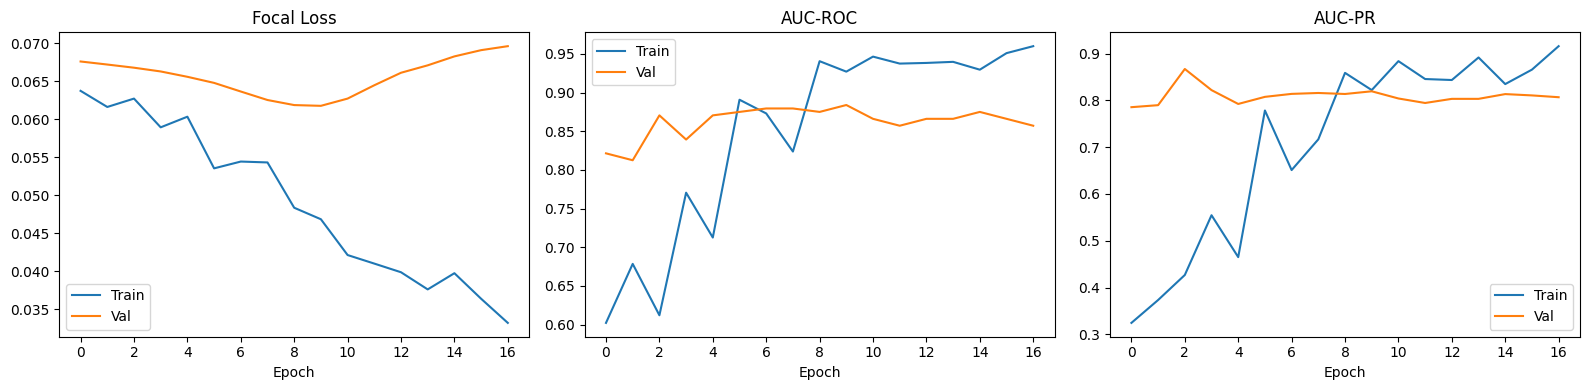

Best epoch = 3
Train AUC-PR @best: 0.4268
Val   AUC-PR @best: 0.8672
Gap (train-val): -0.4404


In [206]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Val")
axes[0].set_title("Focal Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["auc_roc"], label="Train")
axes[1].plot(history.history["val_auc_roc"], label="Val")
axes[1].set_title("AUC-ROC")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history.history["auc_pr"], label="Train")
axes[2].plot(history.history["val_auc_pr"], label="Val")
axes[2].set_title("AUC-PR")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig6_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()

# quick overfitting signal
best_ep = int(np.argmax(history.history["val_auc_pr"]))
train_pr_best = history.history["auc_pr"][best_ep]
val_pr_best = history.history["val_auc_pr"][best_ep]
print(f"Best epoch = {best_ep + 1}")
print(f"Train AUC-PR @best: {train_pr_best:.4f}")
print(f"Val   AUC-PR @best: {val_pr_best:.4f}")
print(f"Gap (train-val): {(train_pr_best - val_pr_best):.4f}")

In [207]:
# Validation threshold tuning
y_val_proba = model.predict(X_val, verbose=0).flatten()

precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
f1_for_thresh = f1_scores[:-1]

idx_f1 = int(np.nanargmax(f1_for_thresh))
th_f1 = float(thresholds[idx_f1])

TARGET_RECALL = 0.90
candidate_idx = np.where(recall[:-1] >= TARGET_RECALL)[0]
if len(candidate_idx) > 0:
    idx_rec = int(candidate_idx[np.argmax(precision[candidate_idx])])
    th_recall = float(thresholds[idx_rec])
else:
    th_recall = th_f1

# Choose operating mode:
# - "balanced_f1": fewer false alarms (default)
# - "high_recall": maximize leak capture
THRESHOLD_MODE = "balanced_f1"
THRESHOLD = th_f1 if THRESHOLD_MODE == "balanced_f1" else th_recall

print("=== THRESHOLD TUNING (Validation) ===")
print(f"Best F1 threshold       : {th_f1:.4f}")
print(f"High-recall threshold   : {th_recall:.4f}")
print(f"Selected mode           : {THRESHOLD_MODE}")
print(f"Selected threshold      : {THRESHOLD:.4f}")
print(f"Best validation F1      : {f1_for_thresh[idx_f1]:.4f}")

np.save(f"{MODEL_DIR}/best_threshold.npy", np.array([THRESHOLD]))
print(f"Saved -> {MODEL_DIR}/best_threshold.npy")

=== THRESHOLD TUNING (Validation) ===
Best F1 threshold       : 0.5156
High-recall threshold   : 0.4653
Selected mode           : balanced_f1
Selected threshold      : 0.5156
Best validation F1      : 0.7273
Saved -> ../models/best_threshold.npy


In [208]:
# Test evaluation
y_test_proba = model.predict(X_test, verbose=0).flatten()
y_test_pred = (y_test_proba >= THRESHOLD).astype(int)

test_roc = roc_auc_score(y_test, y_test_proba)
test_pr = average_precision_score(y_test, y_test_proba)

print("=== TEST RESULTS ===")
print(f"Threshold: {THRESHOLD:.4f}")
print(f"AUC-ROC : {test_roc:.4f}")
print(f"AUC-PR  : {test_pr:.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=["Normal", "Leak"], digits=4, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:")
print(cm)

=== TEST RESULTS ===
Threshold: 0.5156
AUC-ROC : 0.7614
AUC-PR  : 0.6097

              precision    recall  f1-score   support

      Normal     0.7857    1.0000    0.8800        22
        Leak     1.0000    0.2500    0.4000         8

    accuracy                         0.8000        30
   macro avg     0.8929    0.6250    0.6400        30
weighted avg     0.8429    0.8000    0.7520        30

Confusion matrix:
[[22  0]
 [ 6  2]]


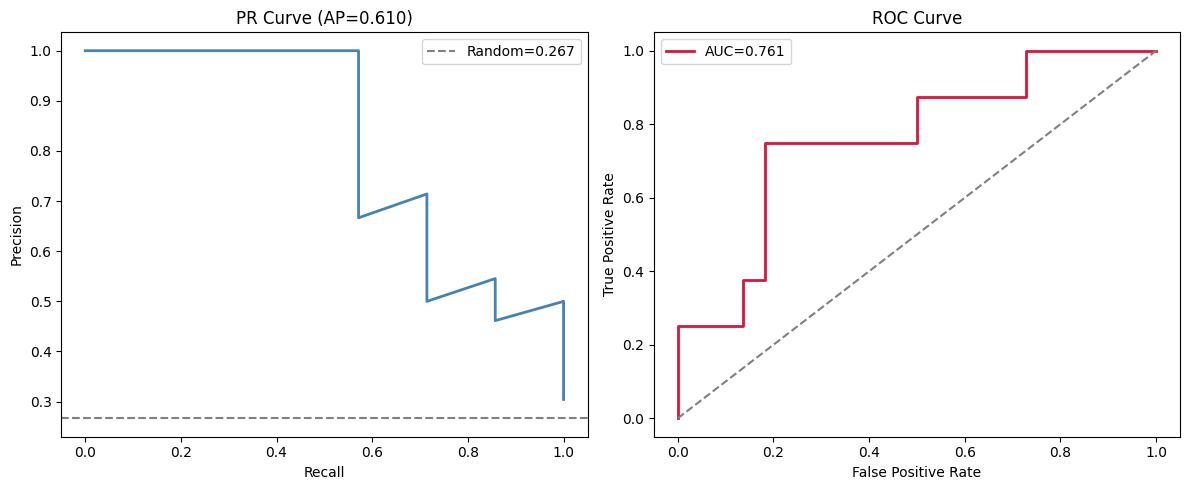

In [209]:
# PR and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PR curve
axes[0].plot(recall, precision, color="steelblue", lw=2)
axes[0].axhline(y_test.mean(), linestyle="--", color="gray", label=f"Random={y_test.mean():.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"PR Curve (AP={test_pr:.3f})")
axes[0].legend()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, color="crimson", lw=2, label=f"AUC={test_roc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig7_pr_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

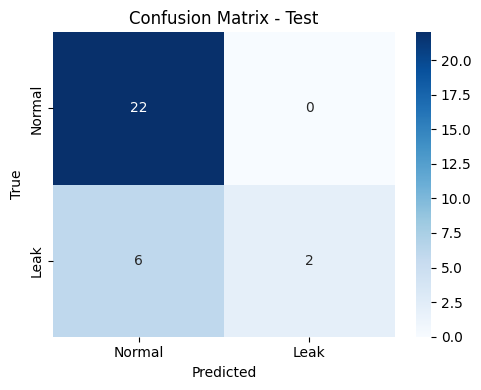

Saved model -> ../models/best_model.keras


In [210]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Leak"],
    yticklabels=["Normal", "Leak"], ax=ax
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix - Test")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig8_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Save final model
model.save(f"{MODEL_DIR}/best_model.keras")
print(f"Saved model -> {MODEL_DIR}/best_model.keras")

In [211]:
# Threshold diagnostics: compare recall-focused vs F1-focused thresholds on test
from sklearn.metrics import precision_score, recall_score, f1_score

candidates = {
    "selected_recall_rule": THRESHOLD,
    "best_f1_on_val": float(th_f1) if 'th_f1' in globals() else THRESHOLD,
}

print("=== THRESHOLD DIAGNOSTICS (TEST) ===")
for name, th in candidates.items():
    pred = (y_test_proba >= th).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    f = f1_score(y_test, pred, zero_division=0)
    print(f"{name:20s} th={th:.4f} | precision={p:.4f} recall={r:.4f} f1={f:.4f}")

=== THRESHOLD DIAGNOSTICS (TEST) ===
selected_recall_rule th=0.5156 | precision=1.0000 recall=0.2500 f1=0.4000
best_f1_on_val       th=0.5156 | precision=1.0000 recall=0.2500 f1=0.4000
